In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv('Student_Marks.csv')
df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


In [4]:
df.describe()

,number_courses,time_study,Marks
count,100.000000,100.000000,100.000000
mean,5.290000,4.077140,24.417690
std,1.799523,2.372914,14.326199
min,3.000000,0.096000,5.609000
25%,4.000000,2.058500,12.633000
50%,5.000000,4.022000,20.059500
75%,7.000000,6.179250,36.676250
max,8.000000,7.957000,55.299000


In [7]:
X = df[['number_courses', 'time_study']]
y = df['Marks']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

model = LinearRegression()
model.fit(X_train, y_train)

r_sq = model.score(X_test, y_test)
print('Coefficient of determination (R^2):', r_sq)

Coefficient of determination (R^2): 0.9415580476324483


In [8]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print('Mean Squared Error:', mse)

Mean Squared Error: 11.38437267846016


In [9]:
print('Intercept:', model.intercept_)
print('Slope (coefficients):', model.coef_)

Intercept: -6.5728980373252135
Slope (coefficients): [1.80849362 5.32429247]


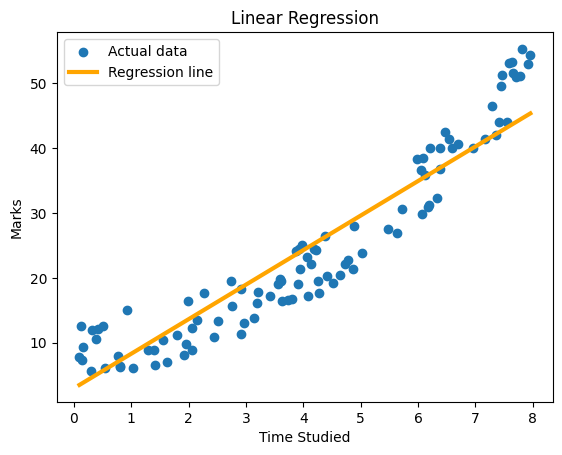

In [12]:
plt.figure()
plt.scatter(df['time_study'], df['Marks'], label='Actual data')

time_range = np.linspace(df['time_study'].min(), df['time_study'].max(), 100)
num_courses_mean = df['number_courses'].mean()

X_line = pd.DataFrame({
    'number_courses': [num_courses_mean] * 100,
    'time_study': time_range
})

y_line = model.predict(X_line)

plt.plot(time_range, y_line, linewidth=3, label='Regression line', color='orange')
plt.xlabel('Time Studied')
plt.ylabel('Marks')
plt.title('Linear Regression')
plt.legend()
plt.show()

In [16]:
predicted_marks = model.predict(X_test)

print('Predicted Marks:\n')
print(*predicted_marks[:10], sep='\n')

Predicted Marks:

8.791297889899745
27.740454795699808
17.34208476235728
21.59622128367585
3.1279896822606954
42.34854751868181
32.91919871513855
7.5258552636573945
48.31175508667734
23.237869183481646
